#Project Name :- Hotel Booking
Project type :- EDA


#Project Summary -
This Project was given to us by the Almabetter team with an intention to understand the Business done by Hotel Group. This Dataset had two hotels City Hotel and Resort Hotel.The data provided was for 3 years 2015 , 2016 and 2017.we also have the revenue and booking details with number of days of stay and booking cancellation,total number of guests including children. It also specifies guests wait period for booking , repetation of guests,their food choices among others.The data also gives us an analysation of countries from which bookings have been done. We also a agent and other channels who also help in business by booking rooms for guests on the resort and city hotel behalf.

The data is divided between city hotel and resort hotel. Hence we can make a fair comparision between both.
Before visualize any data from the data set We will do the data cleaning as to fill any null values and delete any duplicated values and after that we have to do data wrangling.

Also we will do our analysis for both city and resort as individual businesses and in comparision to one another. We will also take help of charts for better analysis. **bold text**

#Problem Statement
This data set contains booking information for a city hotel and a resort hotel, and includes information such as when the booking was made,the number of adults, children, and/or babies, and the number of available parking spaces, which agent made the booking, among other things.

The objective of this project is Explore and analyze the data to discover important factors that govern the bookings.



#Project Objective
Analyse and visualize the data on bookings of City Hotel and Resort Hotel to gain insights on the different factors that affect the booking and ADR.

#**Know Your Data**

In [1]:
# Importing all required libery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading to pandas from csv file
df = pd.read_csv("/content/drive/MyDrive/Python/Pandas/Hotel Bookings (1).csv")


In [2]:
#Data Sample
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Number of Rows and columns
df.shape

(119390, 32)

In [4]:
# Columns Description
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

#Dataset Information


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

# Variables Description

hotel - Type of hotel(Resort or City).

is_canceld - If there was booking cancel(0) or not(1).

lead time - The number of days between time books their room to arrive hotel.

arrival_date_year - Year of arrival date.

arrival_date_month - Month of arrival date.

arrival_date_week_number - Week no. of year for arrival date.

stays_in_weekend_nights - No. of weekend nights(Saturday or sunday) spend by guest at hotel.

stays_in_week_nights -No. of weeknight( Mon to Fri) spend by guest at hotel.

adults - No. of adults among guest.

children - No. of children among guest.

babies - No. of babies among guest.

meal - Type of meal booked by guest.

country - Country of guest.

market_segment - grouping into categories based on their booking patterns and travel habits.

distribution_channel - Name of booking distribution channel.

is_repeated_guest - If the booking was from repeated by guest(1) or not(0).

previous_cancelletions - No. of previous booking that were cancelled by the customer prior to the customer booking.

previous_booking_not_canceled - No. of previous booking that were not cancelled by the customer prior to the customer booking.

reserved_room_type - Code of room type reserved.

assigned_room_type - code of room type reserved.

booking_changes - No. of changes made to the booking.

deposit_type - Type of the deposit made by the guest.

agent - Id of the agent who made the booking.

company - Id of the company that made the booking.

days_in_waiting_list - No. of days the booking on the waiting list.

customer_type - Type of customer, assuming one of four categories.

adr - (Average Daily Rate) dividing the sum of lodgging transaction by the total number of staying night.

required_car_parking_spaces - No. of car parking spaces required by the customer.

total_of_special_request - No. of special request made by the customer.

reservation_request - Reservation status

reservation_request_date - Date of last reservation status updated.

In [6]:
# Creating Copy of data before moving towards data manupulating
df1 = df.copy()

#Duplicate Values

In [7]:
# Checking Duplicates data
df.duplicated().sum()

np.int64(31994)

In [8]:
# Deleting Duplicate Records
df.drop_duplicates(inplace = True)

In [9]:
# Left with Unique records
df.shape


(87396, 32)

In [10]:
# Reset Index
df.reset_index()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87391,119385,City Hotel,0,23,2017,August,35,30,2,5,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
87392,119386,City Hotel,0,102,2017,August,35,31,2,5,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
87393,119387,City Hotel,0,34,2017,August,35,31,2,5,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
87394,119388,City Hotel,0,109,2017,August,35,31,2,5,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


#Handling Null values/ Records

In [11]:
# Checking null values/ Records
null_records = df.isnull().sum()
null_records.sort_values(ascending = False).head()

,0
company,82137
agent,12193
country,452
children,4
arrival_date_month,0


In [12]:
# We have Multiple columns which have null records, we are handling one by one

# Handling Company column which is 90 % empty so we cant get any insight from data, so delete it
df.drop(columns = "company", inplace = True)

# left with 31 columns
df.shape

(87396, 31)

In [13]:
# Handling agent column, which describe booking by agent, so replacing null values with direct booking,
# 1st Fill null values with 0
df["agent"].fillna(0, inplace = True)

# replace 0 in agent with Direct Booking
df["agent"].replace(0, "Direct Bokking", inplace = True)

df.shape

/tmp/ipykernel_11140/3750014628.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["agent"].fillna(0, inplace = True)
/tmp/ipykernel_11140/3750014628.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

(87396, 31)

In [14]:
# Country Column have 452 null records, considering columns describe booking done by people of various country
# and null records assuming people from self country,so replacing null with Local
df["country"].fillna("Local", inplace = True)



/tmp/ipykernel_11140/4232692320.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["country"].fillna("Local", inplace = True)


# Data Wrangling

1. Merge Column to find total person
2. Handling null values in Agent replace with Direct booking
3. Handling null values in Company
4. Handling null Values in Country
5. Reset index after cleaning data
6. Merged Column (Year, Month, Date), Change data type to date.
7. Delete arrival_date_week_number column
8. Add Column Weekend night stay and week night stay and change datatype
9. Remove distribution channel column
10. Added Satisfactory column

In [15]:
# We are going to understand our data and will make changes in data

# Merging Column
# we found out 3 column = Adult , children and babies we can merge them to single column shows total people stays
df["total_person"] = df["adults"] + df['children'] + df['babies']
df.drop(columns = ["adults", "children", "babies"], inplace= True)

# we are going to check if their any null values in the total person cause it is invalid and if so , going to delete null records
df[df["total_person"] == 0]

# Deleting rows
# there are 166 records which contains 0 total person and this is invalid, deleting them

df.drop(df[df['total_person'] == 0].index, inplace = True)

##df.rename(columns = {"Total_person": "total_person"}, inplace = True)



In [16]:
# after deleting rows and column going to reset index
df.reset_index(drop = True, inplace = True)

In [17]:
# Rows after deleting Total person null records and columns
df.shape

(87230, 29)

In [18]:
# Deleting Column
# We have column name arrival_date_week_number which has no significant for our insight thus we are deleting them
df.drop(columns = "arrival_date_week_number", inplace = True)

In [19]:
# Adding Column
# we have stays_in_weekend_nights and stays_in_week_nights columns , so can get the total stay from this columns
df["total_stays"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]


In [20]:
# Deleting Column
# Market Segment and Distribution Channel contained identical data, so one column was removed and no any analytical use
df.drop(columns = "distribution_channel", inplace = True)
df.shape

(87230, 28)

In [21]:
# Adding Column
# data have room asked for and room assigned, from this we can get customer satisfaction.
df["satisfaction"] = df["assigned_room_type"] == df["reserved_room_type"]

df["satisfaction"]

,satisfaction
0,True
1,True
2,False
3,True
4,True
...,...
87225,True
87226,True
87227,True
87228,True


#What do we know about the dataset?

1. The provided dataset pertains to hotel bookings. Our objective is to analyze and explore it to identify key factors that influence booking trends. The dataset consists of 119,390 rows and 32 columns.

2. There are 31,994 duplicate rows present in the data.

3. Four columns contain missing values: company, agent, country, and children.

4. To simplify the data, we will combine the separate adults, children, and babies columns into a single new column called total_num_people, representing the total number of guests

# Data Visualization
## Understanding relationship between variables

In [22]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'meal', 'country',
       'market_segment', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_person',
       'total_stays', 'satisfaction'],
      dtype='object')

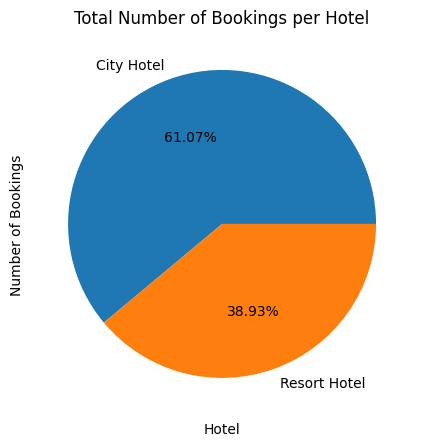

In [23]:
# 1.Most Preferred Hotel
# Total Number of Bookings per Hotel
plt.figure(figsize = (10,5))
df["hotel"].value_counts().plot(kind = "pie",autopct = '%1.2f%%')
plt.title("Total Number of Bookings per Hotel")
plt.xlabel("Hotel")
plt.ylabel("Number of Bookings")
plt.show()
#

1. Why did you pick the specific chart?

I used the pie chart To check and understand the hotel type is resort or city in simple way of visualizing.

2. What is/are the insight(s) found from the chart?

Based on the above observations, I found that 61.07% preferred city hotel and 38.93% preferred to book a resort hotel. Which means Resort hotels have less booking

3. Will the gained insights help creating a positive business impact?

Are there any insights that lead to negative growth? Justify with specific reason.
City hotel can find more services to attract more guests to increase more revenue.

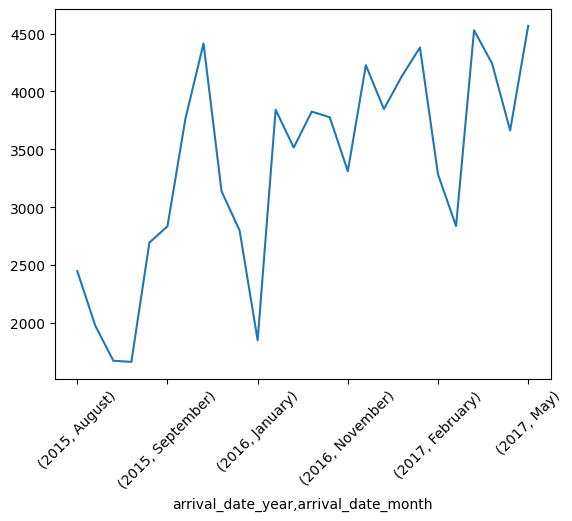

In [24]:
# 2. Year wise bookings
a = df[["arrival_date_year","arrival_date_month"]].value_counts().sort_index()
a.plot(kind = "line")
plt.xticks(rotation = 45)
plt.show()

The chart shows strong seasonal fluctuations with consistent summer peaks and sharp January dips. There is also an overall positive growth trend year-over-year.

These insights lead to positive business impacts through better proactive planning, allowing for optimized pricing strategies and resource allocation.

The data chart displays significant seasonal fluctuations in monthly booking IDs from July 2015 to July 2017. Bookings consistently peak during summer months (July) and drop sharply in January of each year.

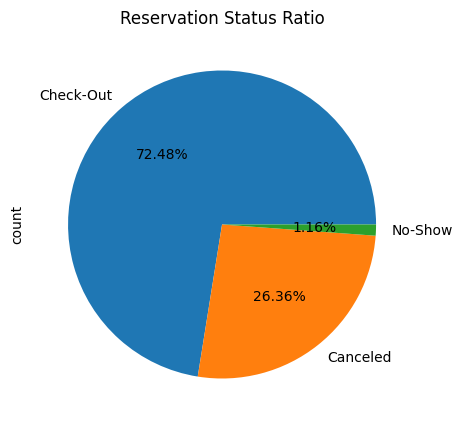

In [25]:
#3. What is reservation status ratio
plt.figure(figsize = (10,5))
df["reservation_status"].value_counts().plot(kind = "pie",autopct = '%1.2f%%')
plt.title("Reservation Status Ratio")
plt.show()

Based on the Donut chart, we can say out of all the bookings, 72.51% of guests Checked-Out, 26.33% of guests Cancelled the booking, while only a small percentage, i.e. 1.16% of guests, were a No-Show.


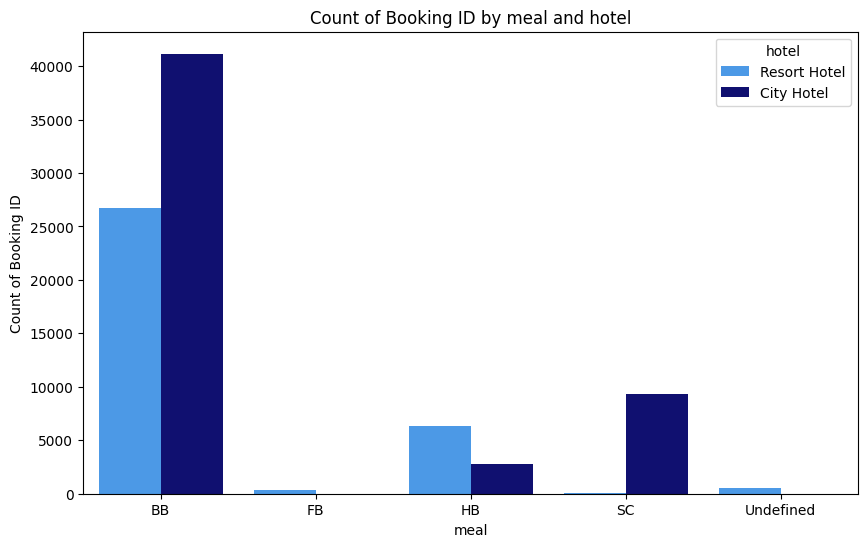

In [26]:
# 4. Most Preferred meal hotel wise

# Set the figure size
plt.figure(figsize=(10, 6))

# Create the grouped bar chart
# 'meal' on the x-axis, 'hotel' creates the side-by-side bars
ax = sns.countplot(data=df, x='meal', hue='hotel', palette=['#3399FF', '#000080'])

# Adding labels and title
plt.title('Count of Booking ID by meal and hotel')
plt.xlabel('meal')
plt.ylabel('Count of Booking ID')

# Show the plot
plt.show()


The Clustered Column chart shows the most preferred meals for guests of different hotels.
Based on the bar chart, we can say that most guests prefer BB meal type, which is approx. 41K people for City Hotel and 27K for Resort Hotel.


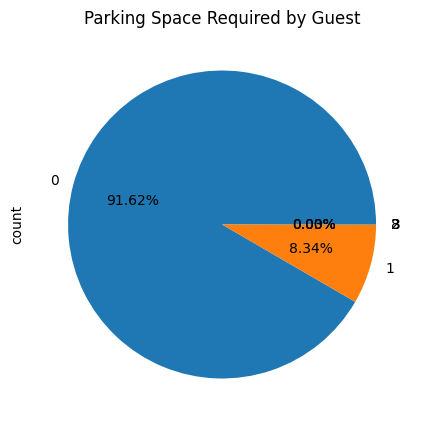

In [27]:
# 5.Parking Space Required by Guest
plt.figure(figsize = (10,5))
df["required_car_parking_spaces"].value_counts().plot(kind="pie", autopct = "%1.2f%%")
plt.title("Parking Space Required by Guest")
plt.show()
#


This Pie chart shows clear ratio for Parking space required by guest.

Most guests (over 90%) don’t need parking, so parking capacity can be limited to reduce costs.

Maintain a small, well-managed allocation for single-space requests to meet demand efficiently.



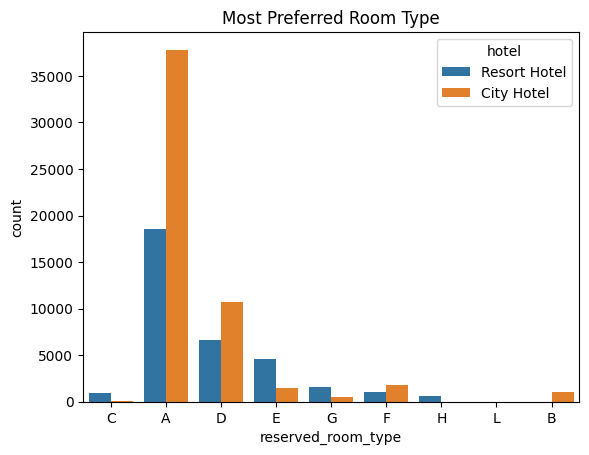

In [28]:
# 6. Most Preferred Room Type

sns.countplot(data = df, x= "reserved_room_type", hue= "hotel")
plt.title("Most Preferred Room Type")
plt.show()


This Clustered column chart shows clear ratio between the preferred room type with hotel type.

Data Shows most preferred rooms are A and D.

We can apply similarities of A and D Rooms to the rest of room to avoid miss assignment and increase satisfaction level of customer


# Conclusion
Top Performance: City hotels are the preferred choice, with peak bookings and revenue recorded in 2016.

Infrastructure: Minimal guest demand for parking suggests that further investment in parking facilities should be limited.

Seasonality: Booking volumes peak annually during July and August, driven by the summer holiday season.

Distribution & Demographics: Most reservations flow through travel agents, with the largest customer bases originating from Portugal, the UK, France, and Spain.

Room & Board: Guests most frequently book Room Types A and D, while Bed & Breakfast (BB) remains the dominant meal plan.
